# Spotify Genre Classification (2022)
This notebook builds a multi-class genre classifier from Spotify audio features. The goal is to predict genre labels from track-level descriptors and compare common model families on the same cleaned dataset.

**Dataset**
- Source file: `SpotifyFeatures.csv`
- Content: Spotify track metadata and audio features (for example, danceability, energy, loudness, key, mode, time signature, and popularity)

**Approach**
- Clean the raw data (missing values check, duplicate removal, and label cleanup)
- Reduce noisy or highly overlapping classes to stabilize training
- Encode categorical variables and scale features per model requirements
- Train and compare SVM, Random Forest, and MLP baselines, then tune each with grid search

**Key findings**
- Baseline accuracy: SVM `0.8003`, Random Forest `0.8194`, MLP `0.8025`
- Tuned accuracy: SVM `0.8088`, Random Forest `0.8218`, MLP `0.8112`
- Random Forest with tuned hyperparameters produced the best overall test accuracy in this notebook


### Notebook setup
We start by importing required libraries, loading the dataset, and validating basic data quality so downstream model comparisons are reliable.


In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [50]:
df = pd.read_csv("SpotifyFeatures.csv")
df.head()


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [51]:
# Check for missing values in the DataFrame
missing_values = pd.isnull(df).sum()

# Print the number of missing values
print(f'Number of missing values: {missing_values}')


Number of missing values: genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64


### Data quality check
We verify missing values first because missing data can bias model training and invalidate comparisons across algorithms. No missing values are found, so we proceed without imputation.


In [52]:
df.dtypes


genre                object
artist_name          object
track_name           object
track_id             object
popularity            int64
acousticness        float64
danceability        float64
duration_ms           int64
energy              float64
instrumentalness    float64
key                  object
liveness            float64
loudness            float64
mode                 object
speechiness         float64
tempo               float64
time_signature       object
valence             float64
dtype: object

### Feature relevance and categorical inspection
We review data types to decide which fields are useful for genre prediction. Identifier fields (`artist_name`, `track_name`, `track_id`) are not predictive, while `time_signature` is kept for distribution checks before encoding.


Text(0.5, 1.0, 'Time_signature Distribution')

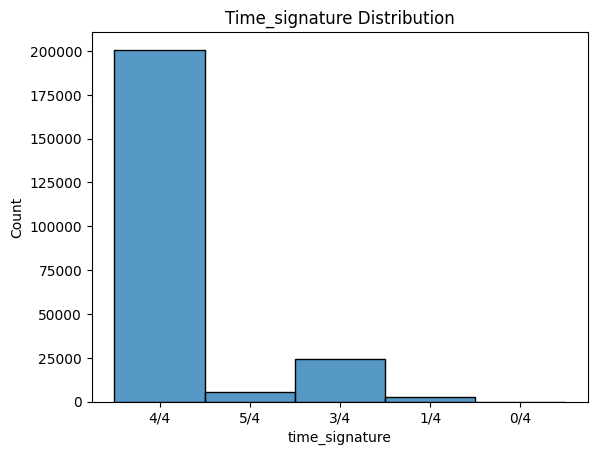

In [53]:
sns.histplot(df['time_signature']).set_title('Time_signature Distribution')


### Filter rare time signatures
Very rare `0/4` and `1/4` entries can add noise and class imbalance, so we remove them to keep the feature space more stable.


In [54]:
df = df[~df['time_signature'].isin(['0/4', '1/4'])]


Text(0.5, 1.0, 'Time Signature Distribution')

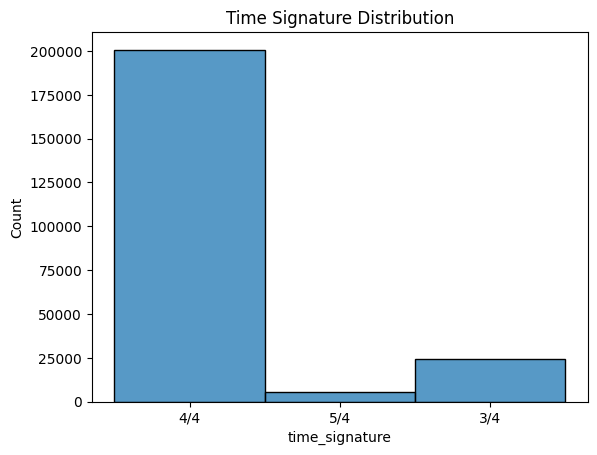

In [55]:
sns.histplot(df['time_signature']).set_title('Time Signature Distribution')


### Check class balance
We inspect genre counts to understand how balanced the target classes are before training. This helps interpret downstream accuracy and per-class metrics.


Text(0.5, 1.0, 'Genre Distribution')

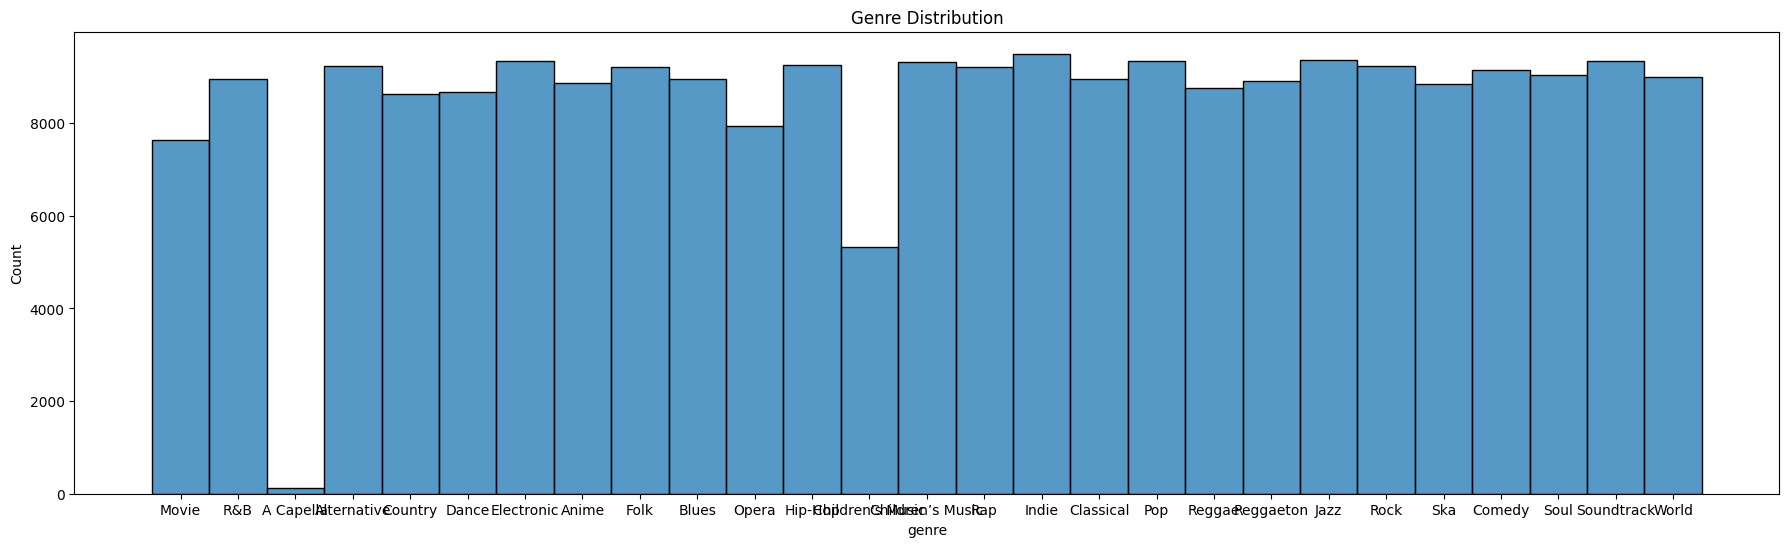

In [56]:
plt.figure(figsize=(22, 6))
sns.histplot(df['genre']).set_title('Genre Distribution')


In [57]:
df['genre'].value_counts().sort_index()


genre
A Capella            114
Alternative         9231
Anime               8858
Blues               8956
Children's Music    5337
Children’s Music    9321
Classical           8953
Comedy              9139
Country             8640
Dance               8678
Electronic          9338
Folk                9221
Hip-Hop             9259
Indie               9499
Jazz                9362
Movie               7629
Opera               7943
Pop                 9352
R&B                 8943
Rap                 9203
Reggae              8753
Reggaeton           8913
Rock                9233
Ska                 8846
Soul                9041
Soundtrack          9347
World               9000
Name: count, dtype: int64

### Remove sparse and inconsistent genre labels
We drop underrepresented labels and inconsistent naming variants to reduce label noise and keep the classification target cleaner.


In [58]:
df = df[~df.genre.isin(['A Capella', 'Children?s Music', "Children's Music"])]


In [59]:
df['genre'].value_counts().sort_index()


genre
Alternative         9231
Anime               8858
Blues               8956
Children’s Music    9321
Classical           8953
Comedy              9139
Country             8640
Dance               8678
Electronic          9338
Folk                9221
Hip-Hop             9259
Indie               9499
Jazz                9362
Movie               7629
Opera               7943
Pop                 9352
R&B                 8943
Rap                 9203
Reggae              8753
Reggaeton           8913
Rock                9233
Ska                 8846
Soul                9041
Soundtrack          9347
World               9000
Name: count, dtype: int64

Text(0.5, 1.0, 'Genre Distribution')

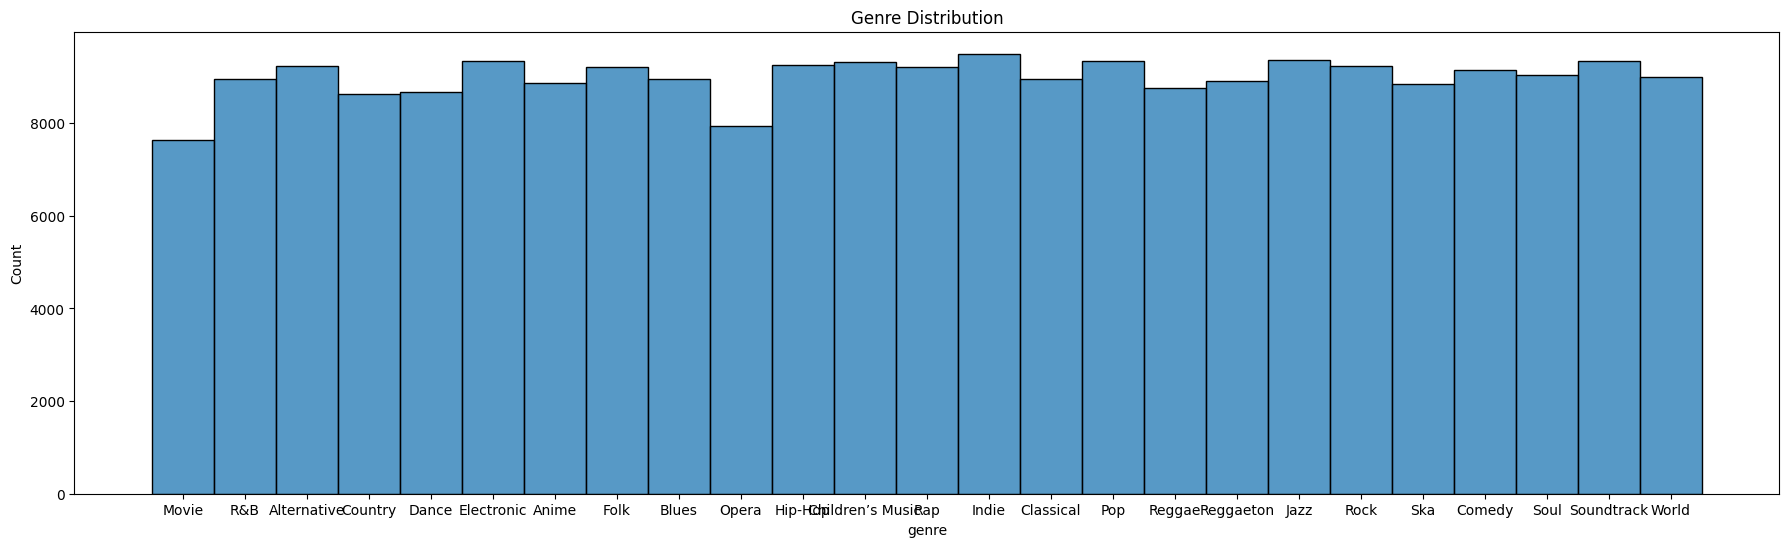

In [60]:
plt.figure(figsize=(22, 6))
sns.histplot(df['genre']).set_title('Genre Distribution')


### Remove duplicate tracks
Duplicate `track_id` rows can leak repeated patterns into train/test splits. We identify and remove duplicates to make evaluation more trustworthy.


In [61]:
# Check for duplicates in the DataFrame
duplicated_all = df[df.duplicated(subset= 'track_id' , keep=False)]
duplicated = df[df.duplicated(subset='track_id', keep='first')]

# Get the number of unique duplicates and total duplicates
num_unique_duplicates = duplicated.shape[0]
num_total_duplicates = duplicated_all.shape[0]

# Get the total number of rows in the DataFrame
num_total_rows = df.shape[0]

# Calculate the proportion of duplicates in the DataFrame
duplicates_proportion = round(num_total_duplicates / num_total_rows * 100, 2)

# Print the results
print(f'Number of unique duplicates: {num_unique_duplicates}')
print(f'Number of total duplicates: {num_total_duplicates}')
print(f'Total number of rows: {num_total_rows}')
print(f'Proportion of duplicates: {duplicates_proportion}%')


Number of unique duplicates: 55685
Number of total duplicates: 90618
Total number of rows: 224658
Proportion of duplicates: 40.34%


In [62]:
df_new = df.drop_duplicates(subset = 'track_id', keep=False)
df_new = df_new.reset_index(drop=True)

X=df_new.drop(['track_id'],axis=1)
X['genre'].value_counts().sort_index()


genre
Alternative         1808
Anime               8493
Blues               7197
Children’s Music     600
Classical           7778
Comedy              9131
Country             6506
Dance               2730
Electronic          8152
Folk                4302
Hip-Hop             1891
Indie               1965
Jazz                7122
Movie               7312
Opera               7567
Pop                 1320
R&B                 2708
Rap                  976
Reggae              7673
Reggaeton           8512
Rock                1854
Ska                 7989
Soul                4385
Soundtrack          8186
World               7883
Name: count, dtype: int64

### Rebalance after deduplication
After deduplication, class proportions shift. We trim selected genres to reduce imbalance and avoid models overfitting dominant categories.


In [63]:
X = df_new.drop(df_new[df_new['genre'].isin(['World','Reggaeton','Pop','Alternative','Dance','Hip-Hop','R&B','Rock','Rap','Indie'])].index)
X.reset_index(drop=True, inplace=True)
X['genre'].value_counts().sort_index()


genre
Anime               8493
Blues               7197
Children’s Music     600
Classical           7778
Comedy              9131
Country             6506
Electronic          8152
Folk                4302
Jazz                7122
Movie               7312
Opera               7567
Reggae              7673
Ska                 7989
Soul                4385
Soundtrack          8186
Name: count, dtype: int64

### Reduce overlap between similar genres
Some genres are musically close and harder to separate. We create a reduced-genre subset to test model performance on clearer boundaries.


In [64]:
# The genres Blues, Classical, Opera, and Soundtrack are less likely to overlap musically
X.drop(X[X['genre'].isin(['Soundtrack','Blues','Folk','Opera','Reggae','Soul','Ska','Comedy','Movie','Anime'])].index, inplace=True)
X['genre'].value_counts().sort_index()


genre
Children’s Music     600
Classical           7778
Country             6506
Electronic          8152
Jazz                7122
Name: count, dtype: int64

### Data decision tradeoff
We intentionally trimmed many genres to reduce class imbalance and label overlap before modeling. This improves separability and often boosts apparent accuracy, but it narrows coverage and discards potentially useful edge cases. Practical alternatives include class-weighted training and synthetic resampling (e.g., SMOTE) to preserve more of the original genre diversity.


In [65]:
# Quantify the effect of genre filtering decisions
first_drop_genres = ['World','Reggaeton','Pop','Alternative','Dance','Hip-Hop','R&B','Rock','Rap','Indie']
second_drop_genres = ['Soundtrack','Blues','Folk','Opera','Reggae','Soul','Ska','Comedy','Movie','Anime']

stage_1 = df_new.copy()
stage_2 = stage_1[~stage_1['genre'].isin(first_drop_genres)].copy()
stage_3 = stage_2[~stage_2['genre'].isin(second_drop_genres)].copy()

tradeoff_summary = pd.DataFrame(
    {
        'Stage': [
            'After deduplication',
            'After first genre trim',
            'Final reduced-genre dataset',
        ],
        'Samples': [len(stage_1), len(stage_2), len(stage_3)],
        'Genres': [stage_1['genre'].nunique(), stage_2['genre'].nunique(), stage_3['genre'].nunique()],
    }
)
tradeoff_summary['Sample Retention'] = (tradeoff_summary['Samples'] / tradeoff_summary.loc[0, 'Samples']).round(3)
tradeoff_summary


,Stage,Samples,Genres,Sample Retention
0,After deduplication,134040,25,1.000
1,After first genre trim,102393,15,0.764
2,Final reduced-genre dataset,30158,5,0.225


### Encode categorical features
Models require numeric inputs, so we encode categorical columns (`genre`, `mode`, `time_signature`, `key`) before training.


In [66]:
# Convert the mode, genre, time_signature, key features to strings
X['genre'] = X['genre'].astype(str)
X['mode'] = X['mode'].astype(str)
X['time_signature'] = X['time_signature'].astype(str)
X['key'] = X['key'].astype(str)

# Create a label encoder
le = LabelEncoder()

# Fit the label encoder to the mode feature and transform the mode feature using the label encoder
le.fit(X['mode'])
X['mode'] = le.transform(X['mode'])

# Fit the label encoder to the time_signature feature and transform the time_signature feature using the label encoder
le.fit(X['time_signature'])
X['time_signature'] = le.transform(X['time_signature'])

# Fit the label encoder to the 'key' feature and transform the feature using the label encoder
le.fit(X['key'])
X['key'] = le.transform(X['key'])

# Fit the label encoder to the 'genre' feature and transform the feature using the label encoder
le.fit(X['genre'])
X['genre'] = le.transform(X['genre'])


In [19]:
X.head()


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
395,2,Cam,My Mistake,5ICoYTFfmUKguBHpINKkGL,45,0.00821,0.551,200013,0.704,0.000002,11,0.2450,-5.426,0,0.0444,97.075,1,0.541
396,2,Kevin Fowler,That Girl,0rk6JE7ODyGWWquK4y7t1u,42,0.02720,0.375,208187,0.859,0.000000,10,0.2670,-3.243,0,0.0569,74.059,1,0.597
397,2,Chris Cagle,Anywhere But Here,2JxSaSRavL82FCTCPzVmEf,42,0.57100,0.640,243000,0.478,0.000000,2,0.0902,-6.960,0,0.0330,136.717,1,0.315
398,2,Cassadee Pope,I Wish I Could Break Your Heart,4wrjIq1lskP8tZuQBEdcux,44,0.13000,0.435,220413,0.846,0.000000,11,0.0920,-4.169,0,0.0496,199.895,1,0.631
399,2,Mark Chesnutt,Too Cold At Home,5oqxLuRvQFjV4k0orrXs5d,41,0.19900,0.638,219573,0.412,0.000009,5,0.3190,-12.901,0,0.0242,92.832,1,0.509


Text(0.5, 1.0, 'Key usage by genre')

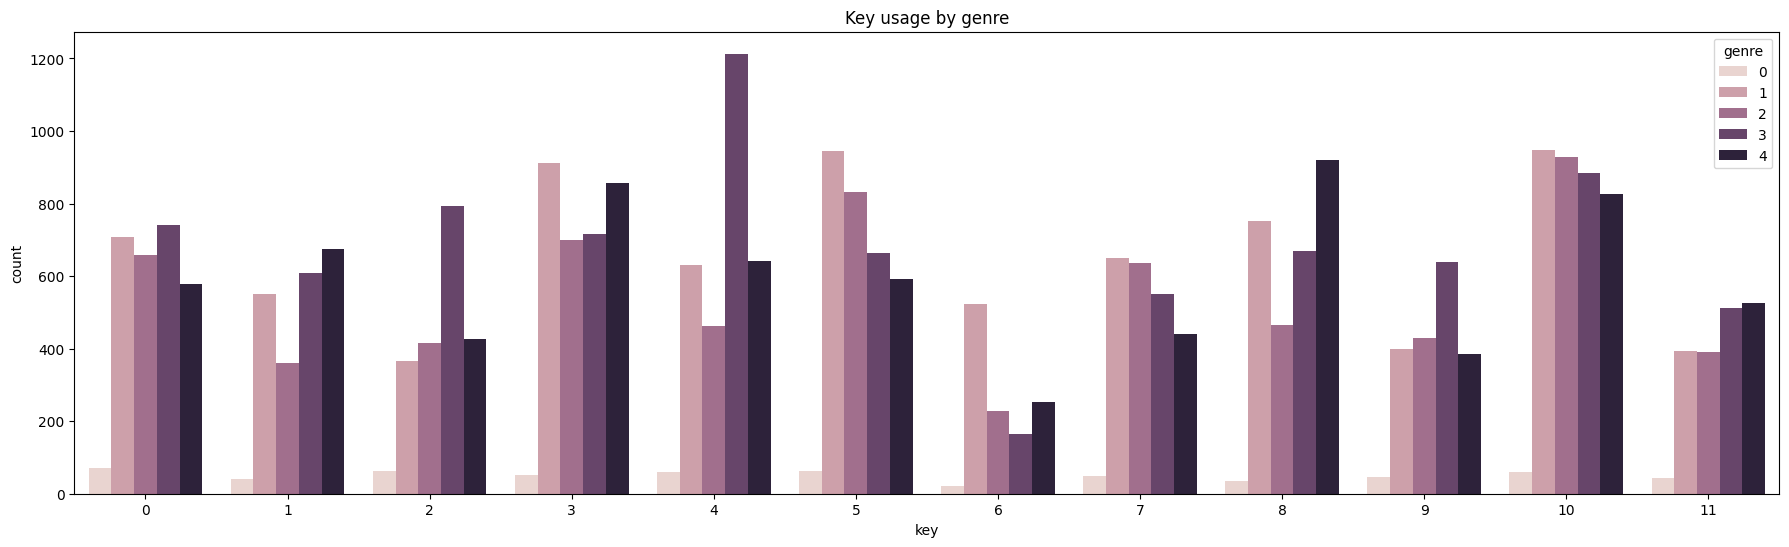

In [67]:
plt.figure(figsize=(22, 6))
sns.countplot(x = 'key', hue = 'genre', data = X)
plt.title('Key usage by genre')


Text(0.5, 1.0, 'Mode usage by genre')

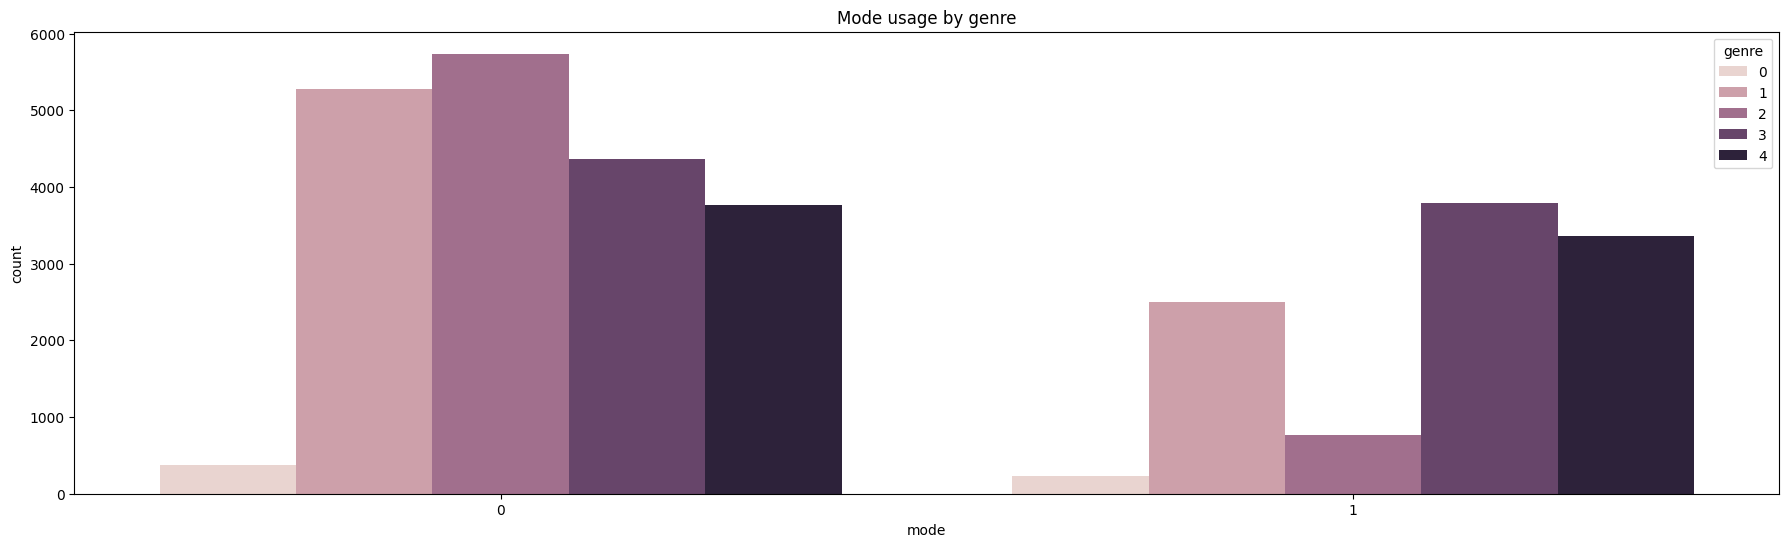

In [21]:
plt.figure(figsize=(22, 6))
sns.countplot(x = 'mode', hue = 'genre', data = X)
plt.title('Mode usage by genre')


Text(0.5, 1.0, 'Time signature usage by genre')

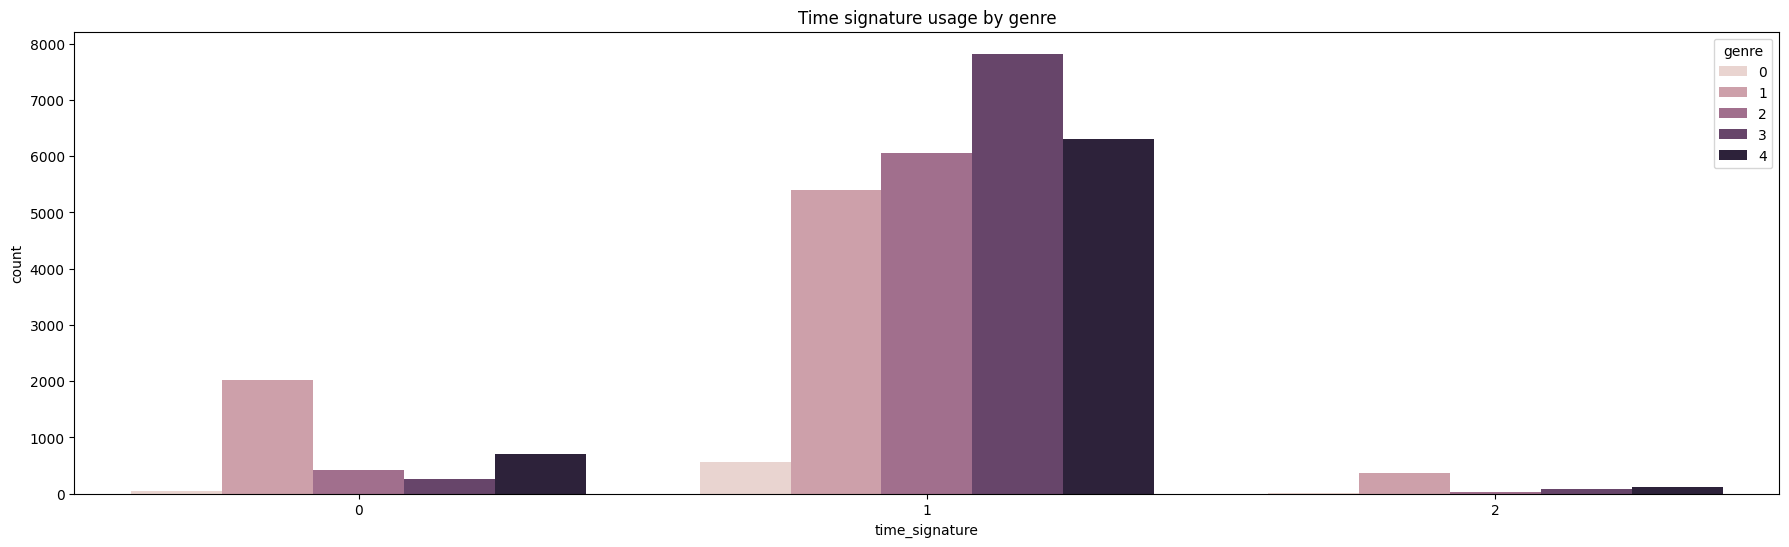

In [22]:
plt.figure(figsize=(22, 6))
sns.countplot(x = 'time_signature', hue = 'genre', data = X)
plt.title('Time signature usage by genre')


Text(0.5, 1.0, 'Popularity distribution by genre')

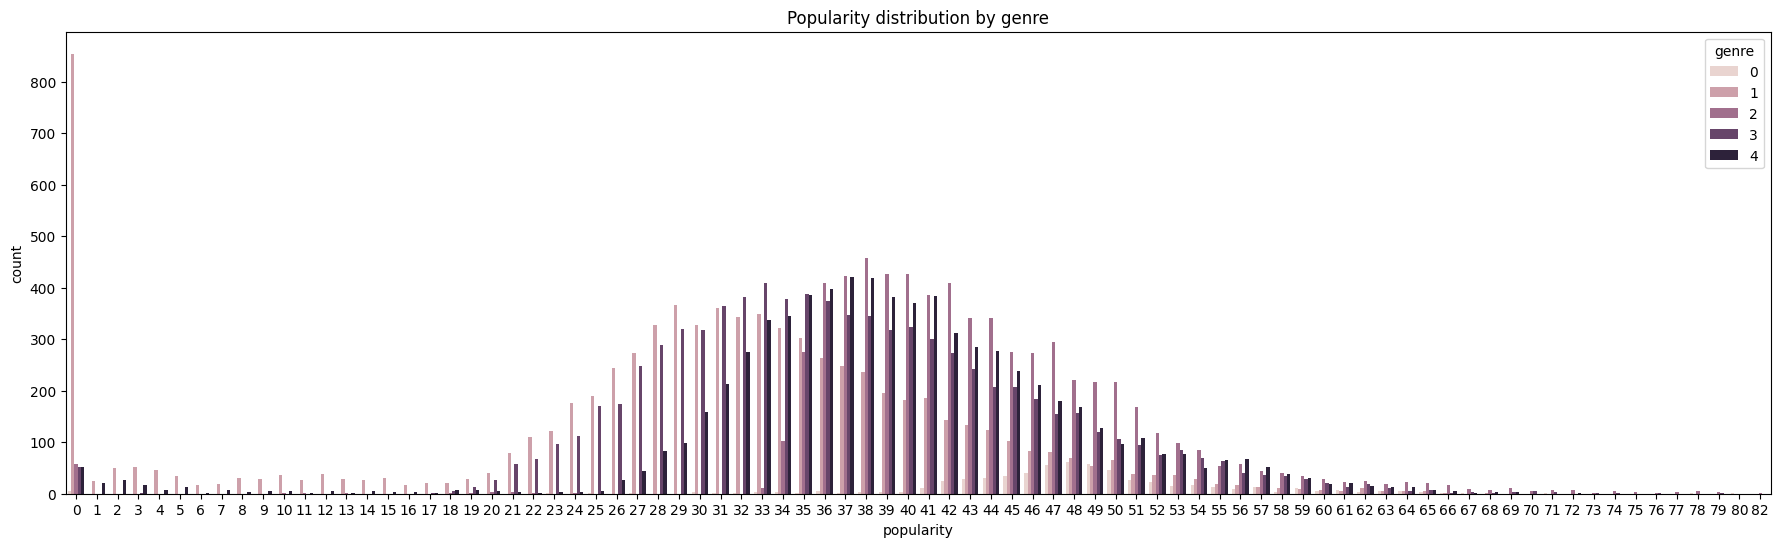

In [23]:
plt.figure(figsize=(22, 6))
sns.countplot(x = 'popularity', hue = 'genre', data = X)
plt.title('Popularity distribution by genre')


### Categorical feature diagnostics
These plots check whether `key`, `mode`, `time_signature`, and `popularity` provide discriminative signal by genre. This informs which features to keep.


In [24]:
# Removing 'mode', 'key', 'popularity'
# Defining X and y
y = X['genre']
X = X.drop(['track_name','artist_name','track_id','popularity','genre','key','mode'],axis = 1)


In [25]:
X.head()


,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature,valence
395,0.00821,0.551,200013,0.704,0.000002,0.2450,-5.426,0.0444,97.075,1,0.541
396,0.02720,0.375,208187,0.859,0.000000,0.2670,-3.243,0.0569,74.059,1,0.597
397,0.57100,0.640,243000,0.478,0.000000,0.0902,-6.960,0.0330,136.717,1,0.315
398,0.13000,0.435,220413,0.846,0.000000,0.0920,-4.169,0.0496,199.895,1,0.631
399,0.19900,0.638,219573,0.412,0.000009,0.3190,-12.901,0.0242,92.832,1,0.509


### Correlation heatmap before modeling
A feature-correlation view helps identify redundant predictors and potential multicollinearity before training.


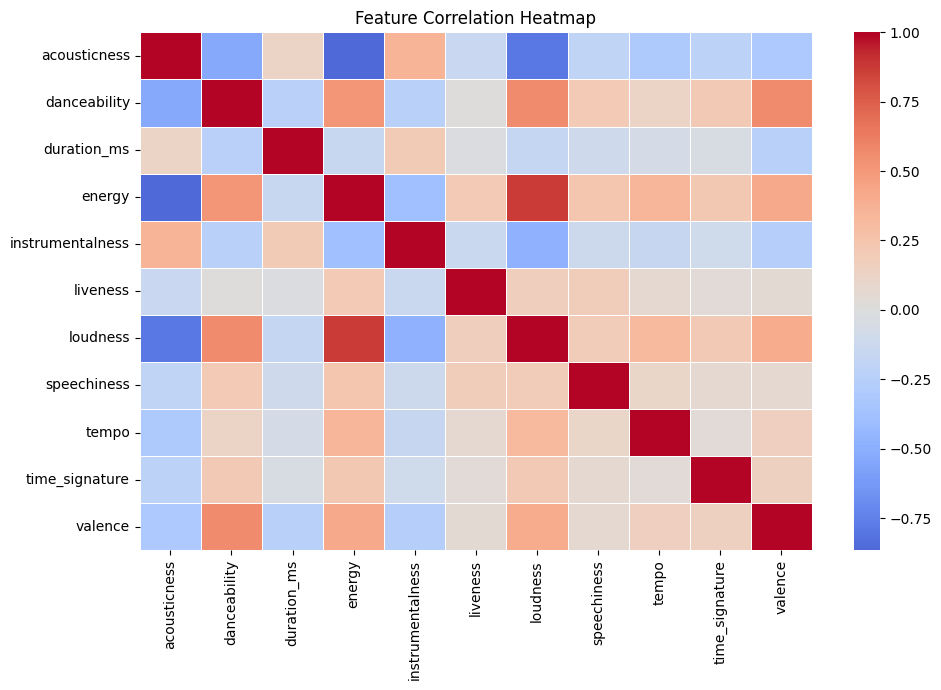

In [26]:
# Correlation heatmap for the selected numeric predictors
corr_matrix = X.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=False,
    linewidths=0.5,
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


## Training and evaluation strategy
We compare SVM, Random Forest, and MLP on the same prepared dataset so performance differences come from model choice rather than preprocessing drift.


In [27]:
# Set the seed for reproducibility
np.random.seed(42)

# Convert dataframe to numpy array
X_final = np.array(X)
y_final = np.array(y)


### Support Vector Machine
SVM is a strong baseline for high-dimensional classification, so we evaluate both default and tuned configurations.


In [28]:
# Shuffle data
X_final, y_final = shuffle(X_final, y_final)

# Split data into training and testing set
X_train, X_test, y_train, y_test = train_test_split( X_final , y_final , test_size=0.2 , random_state=42 ) 


In [29]:
# Scaling our data 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [30]:
%%time
# Defining our model
clf_svm = SVC()

# Training our train data without hyperparameter tuning
clf_svm.fit(X_train,y_train)
predict_svm = clf_svm.predict(X_test)

# Measuring accuracy
accuracy_svm = accuracy_score(y_test, predict_svm)
print('The accuracy of SVM model without hyperparameter tuning is: %f' % accuracy_svm)
print(classification_report(y_test, predict_svm))


The accuracy of SVM model without hyperparameter tuning is: 0.785312
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       111
           1       0.91      0.87      0.89      1563
           2       0.74      0.84      0.79      1260
           3       0.76      0.79      0.78      1629
           4       0.73      0.69      0.71      1469

    accuracy                           0.79      6032
   macro avg       0.63      0.64      0.63      6032
weighted avg       0.77      0.79      0.78      6032

CPU times: user 8.23 s, sys: 908 ms, total: 9.14 s
Wall time: 9.14 s


/home/marios/Anastasia/Spotify_Classification/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marios/Anastasia/Spotify_Classification/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/marios/Anastasia/Spotify_Classification/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [31]:
%%time
# Finding best hyperparameters
param_svm_={'C':[1,10,100],
       'kernel':('linear','poly','rbf'),
       'degree' : [1,2,4,6]
       }

# Define model 
clf_svm_best = SVC()
model_svm_best = GridSearchCV(clf_svm_best,param_svm_)

# Fitting best parameters given by GridSearchCV function 
model_svm_best.fit(X_train,y_train)
print("The best hyperparameters are :",model_svm_best.best_params_ )

# Assessing performance with a test that wasnt part of the training with the best hyperparameters
predict_svm_best = model_svm_best.predict(X_test)
accuracy_of_best_svm_ = accuracy_score(y_test, predict_svm_best)
print('Accuracy with the best hyperparameters: %f' % accuracy_of_best_svm_)
print(classification_report(y_test, predict_svm_best))


The best hyperparameters are : {'C': 10, 'degree': 1, 'kernel': 'rbf'}
Accuracy with the best hyperparameters: 0.795093
              precision    recall  f1-score   support

           0       0.14      0.01      0.02       111
           1       0.90      0.89      0.90      1563
           2       0.76      0.84      0.80      1260
           3       0.78      0.80      0.79      1629
           4       0.73      0.71      0.72      1469

    accuracy                           0.80      6032
   macro avg       0.66      0.65      0.64      6032
weighted avg       0.78      0.80      0.79      6032

CPU times: user 1h 47min 25s, sys: 3.49 s, total: 1h 47min 28s
Wall time: 1h 47min 28s


In [32]:
# Save tuned SVM test labels/predictions for final model comparison visuals
y_test_svm_best = y_test.copy()
predict_svm_best_saved = predict_svm_best.copy()


### Random Forest
Random Forest captures non-linear feature interactions and often performs well on tabular audio descriptors.


In [33]:
# Shuffle data
X_final, y_final = shuffle(X_final, y_final)

# Split data into training and testing set
X_train, X_test, y_train, y_test = train_test_split( X_final , y_final , test_size=0.2 , random_state=42 ) 


In [34]:
# Scaling our data 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [35]:
%%time
# Define Model 
clf_rf = RandomForestClassifier()

# Training our train data without hyperparameter tuning
clf_rf.fit(X_train, y_train)
predict_rf = clf_rf.predict(X_test)

# Measuring accuracy
accuracy_rf = accuracy_score(y_test, predict_rf)
print('The accuracy of Random Forests model without hyperparameter tuning is: %f'% accuracy_rf)
print(classification_report(y_test, predict_rf))


The accuracy of Random Forests model without hyperparameter tuning is: 0.803714
              precision    recall  f1-score   support

           0       0.62      0.04      0.08       121
           1       0.90      0.90      0.90      1528
           2       0.78      0.86      0.82      1307
           3       0.80      0.81      0.80      1624
           4       0.73      0.71      0.72      1452

    accuracy                           0.80      6032
   macro avg       0.77      0.66      0.66      6032
weighted avg       0.80      0.80      0.80      6032

CPU times: user 4.64 s, sys: 0 ns, total: 4.64 s
Wall time: 4.64 s


In [36]:
# Finding best Random Forest hyperparameters
param_rf_ = {'n_estimators': [5,20,50,70,100],
            'max_depth': [5, 10, 15, 20,50,70,90,110,None],
            'min_samples_leaf': [1,2,4,6,8,10],
            'min_samples_split': [1,4,8,12,15],
            'criterion': ['gini', 'entropy']}

# Define model
clf_rf_best = RandomForestClassifier()
model_rf_best =GridSearchCV(clf_rf_best,param_rf_)

# Fitting best parameters given by GridSearchCV function 
# to a shuffled train set
model_rf_best.fit(X_train,y_train)

print("The best hyperparameters are :",model_rf_best.best_params_ )

# Assessing performance with a test that wasnt part of the training with the best hyperparameters
predict_rf_best = model_rf_best.predict(X_test)
accuracy_of_best_rf_ = accuracy_score(y_test, predict_rf_best)
print(' Accuracy with the best hyperparameters: %f' % accuracy_of_best_rf_)
print(classification_report(y_test, predict_rf_best))


/home/marios/Anastasia/Spotify_Classification/venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
2700 fits failed out of a total of 13500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2700 fits failed with the following error:
Traceback (most recent call last):
  File "/home/marios/Anastasia/Spotify_Classification/venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/marios/Anastasia/Spotify_Classification/venv/lib/python3.10/site-packages/sklearn/base.py", line 1358, in wrapper
    estimator._validate_params()
  File "/home/marios/Anastasia/Spotify_Classification/venv/lib/pytho

The best hyperparameters are : {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 8, 'n_estimators': 100}
 Accuracy with the best hyperparameters: 0.806366
              precision    recall  f1-score   support

           0       0.17      0.01      0.02       121
           1       0.91      0.90      0.90      1528
           2       0.78      0.86      0.82      1307
           3       0.80      0.81      0.80      1624
           4       0.74      0.72      0.73      1452

    accuracy                           0.81      6032
   macro avg       0.68      0.66      0.65      6032
weighted avg       0.80      0.81      0.80      6032



In [37]:
# Save tuned Random Forest test labels/predictions for final model comparison visuals
y_test_rf_best = y_test.copy()
predict_rf_best_saved = predict_rf_best.copy()


### Multi-layer Perceptron
MLP tests whether a neural-network approach improves performance after feature scaling.


In [38]:
# Shuffle data
X_final, y_final = shuffle(X_final, y_final)

# Split data into training and testing set
X_train, X_test, y_train, y_test = train_test_split( X_final , y_final , test_size=0.2 , random_state=42 ) 


In [39]:
# Scaling our data 
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [40]:
%%time
# Let's try with a Neural Network
# Define Model 
clf_mlp = MLPClassifier()

# Training our train data without hyperparameter tuning
clf_mlp.fit(X_train, y_train)
predict_mlp = clf_mlp.predict(X_test)

# Measuring accuracy
accuracy_mlp = accuracy_score(y_test, predict_mlp)
print('The accuracy of MLP model without hyperparameter tuning is %f'% accuracy_mlp)
print(classification_report(y_test, predict_mlp))


The accuracy of MLP model without hyperparameter tuning is 0.787467
              precision    recall  f1-score   support

           0       0.67      0.02      0.03       113
           1       0.89      0.88      0.89      1602
           2       0.77      0.85      0.81      1266
           3       0.76      0.81      0.78      1599
           4       0.72      0.66      0.69      1452

    accuracy                           0.79      6032
   macro avg       0.76      0.64      0.64      6032
weighted avg       0.79      0.79      0.78      6032

CPU times: user 8.56 s, sys: 16 ms, total: 8.57 s
Wall time: 8.37 s


/home/marios/Anastasia/Spotify_Classification/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [43]:
%%time 
# Define Model 
mlp_gs = MLPClassifier()
parameter_space = {
    'hidden_layer_sizes': [(100, 100), (100, 100, 100), (100, 100, 100, 100)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd','adam'],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'max_iter': [500]
}

# Fitting best parameters given by GridSearchCV function 
clf = GridSearchCV(mlp_gs, parameter_space, n_jobs=-1, cv=5, scoring='accuracy', verbose=10, error_score="raise")
best_clf = clf.fit(X_train, y_train) 

# best score achieved during the GridSearchCV
# FIXED: Changed the physical line breaks to \n
print('GridSearch CV best score : {:.4f}\n'.format(clf.best_score_))

# print parameters that give the best results
# FIXED: Combined the string and removed the illegal line breaks
print('Parameters that give the best results :\n', clf.best_params_)

# Assessing performance with a test that wasn't part of the training
predict_mlp_best = best_clf.predict(X_test)
accuracy_of_best_mlp_ = accuracy_score(y_test, predict_mlp_best)
print('Accuracy with the best hyperparameters: %f' % accuracy_of_best_mlp_)
print(classification_report(y_test, predict_mlp_best))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV 2/5; 1/48] START activation=tanh, alpha=0.0001, hidden_layer_sizes=(100, 100), max_iter=500, solver=sgd
[CV 4/5; 1/48] START activation=tanh, alpha=0.0001, hidden_layer_sizes=(100, 100), max_iter=500, solver=sgd
[CV 2/5; 3/48] START activation=tanh, alpha=0.0001, hidden_layer_sizes=(100, 100, 100), max_iter=500, solver=sgd
[CV 2/5; 2/48] START activation=tanh, alpha=0.0001, hidden_layer_sizes=(100, 100), max_iter=500, solver=adam
[CV 3/5; 1/48] START activation=tanh, alpha=0.0001, hidden_layer_sizes=(100, 100), max_iter=500, solver=sgd
[CV 5/5; 2/48] START activation=tanh, alpha=0.0001, hidden_layer_sizes=(100, 100), max_iter=500, solver=adam
[CV 1/5; 2/48] START activation=tanh, alpha=0.0001, hidden_layer_sizes=(100, 100), max_iter=500, solver=adam
[CV 3/5; 2/48] START activation=tanh, alpha=0.0001, hidden_layer_sizes=(100, 100), max_iter=500, solver=adam
[CV 5/5; 1/48] START activation=tanh, alpha=0.0001, hidden_layer_

/home/marios/Anastasia/Spotify_Classification/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 4/5; 1/48] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(100, 100), max_iter=500, solver=sgd;, score=0.745 total time= 1.5min
[CV 1/5; 5/48] START activation=tanh, alpha=0.0001, hidden_layer_sizes=(100, 100, 100, 100), max_iter=500, solver=sgd


/home/marios/Anastasia/Spotify_Classification/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 5/5; 1/48] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(100, 100), max_iter=500, solver=sgd;, score=0.753 total time= 1.5min
[CV 2/5; 5/48] START activation=tanh, alpha=0.0001, hidden_layer_sizes=(100, 100, 100, 100), max_iter=500, solver=sgd


...

/home/marios/Anastasia/Spotify_Classification/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 4/5; 47/48] END activation=relu, alpha=0.1, hidden_layer_sizes=(100, 100, 100, 100), max_iter=500, solver=sgd;, score=0.766 total time= 1.6min


/home/marios/Anastasia/Spotify_Classification/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 5/5; 47/48] END activation=relu, alpha=0.1, hidden_layer_sizes=(100, 100, 100, 100), max_iter=500, solver=sgd;, score=0.775 total time= 1.6min
GridSearch CV best score : 0.7908

Parameters that give the best results :
 {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 100), 'max_iter': 500, 'solver': 'adam'}
Accuracy with the best hyperparameters: 0.789456
              precision    recall  f1-score   support

           0       0.25      0.04      0.08       113
           1       0.89      0.89      0.89      1602
           2       0.76      0.88      0.82      1266
           3       0.76      0.80      0.78      1599
           4       0.74      0.64      0.69      1452

    accuracy                           0.79      6032
   macro avg       0.68      0.65      0.65      6032
weighted avg       0.78      0.79      0.78      6032

CPU times: user 5min 18s, sys: 1.32 s, total: 5min 19s
Wall time: 27min 34s


/home/marios/Anastasia/Spotify_Classification/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [44]:
# Save tuned MLP test labels/predictions for final model comparison visuals
y_test_mlp_best = y_test.copy()
predict_mlp_best_saved = predict_mlp_best.copy()


## Final Model Comparison and Interpretation
This section compares baseline vs tuned performance across all models, visualizes the gains, and inspects the top model with a confusion matrix.


In [45]:
# Baseline vs tuned accuracy summary table for SVM, Random Forest, and MLP
summary_df = pd.DataFrame(
    {
        'Model': ['SVM', 'Random Forest', 'MLP'],
        'Baseline Accuracy': [accuracy_svm, accuracy_rf, accuracy_mlp],
        'Tuned Accuracy': [accuracy_of_best_svm_, accuracy_of_best_rf_, accuracy_of_best_mlp_],
    }
)
summary_df['Improvement'] = summary_df['Tuned Accuracy'] - summary_df['Baseline Accuracy']
summary_df = summary_df.sort_values('Tuned Accuracy', ascending=False).reset_index(drop=True)

summary_df.style.format(
    {
        'Baseline Accuracy': '{:.4f}',
        'Tuned Accuracy': '{:.4f}',
        'Improvement': '{:+.4f}',
    }
)


,Model,Baseline Accuracy,Tuned Accuracy,Improvement
0,Random Forest,0.8037,0.8064,+0.0027
1,SVM,0.7853,0.7951,+0.0098
2,MLP,0.7875,0.7895,+0.0020


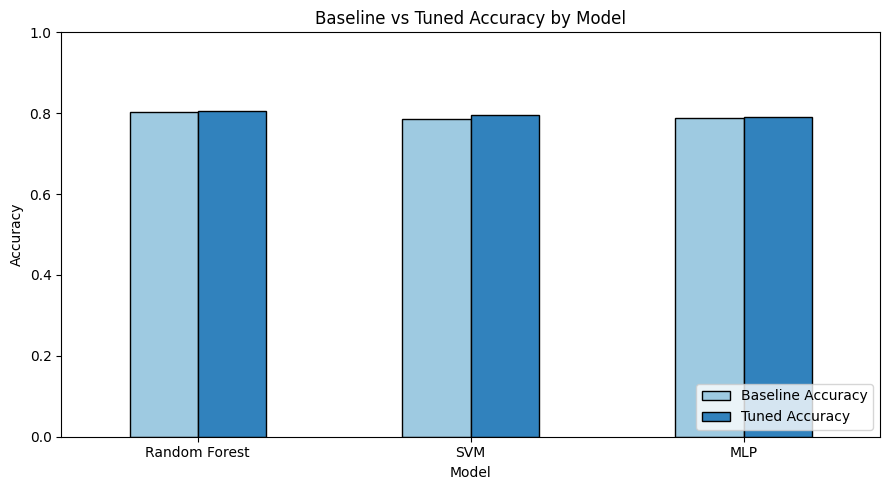

In [46]:
# Bar chart comparing baseline and tuned accuracy across models
plot_df = summary_df.set_index('Model')[['Baseline Accuracy', 'Tuned Accuracy']]
ax = plot_df.plot(
    kind='bar',
    figsize=(9, 5),
    color=['#9ecae1', '#3182bd'],
    edgecolor='black',
)
ax.set_title('Baseline vs Tuned Accuracy by Model')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Model')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


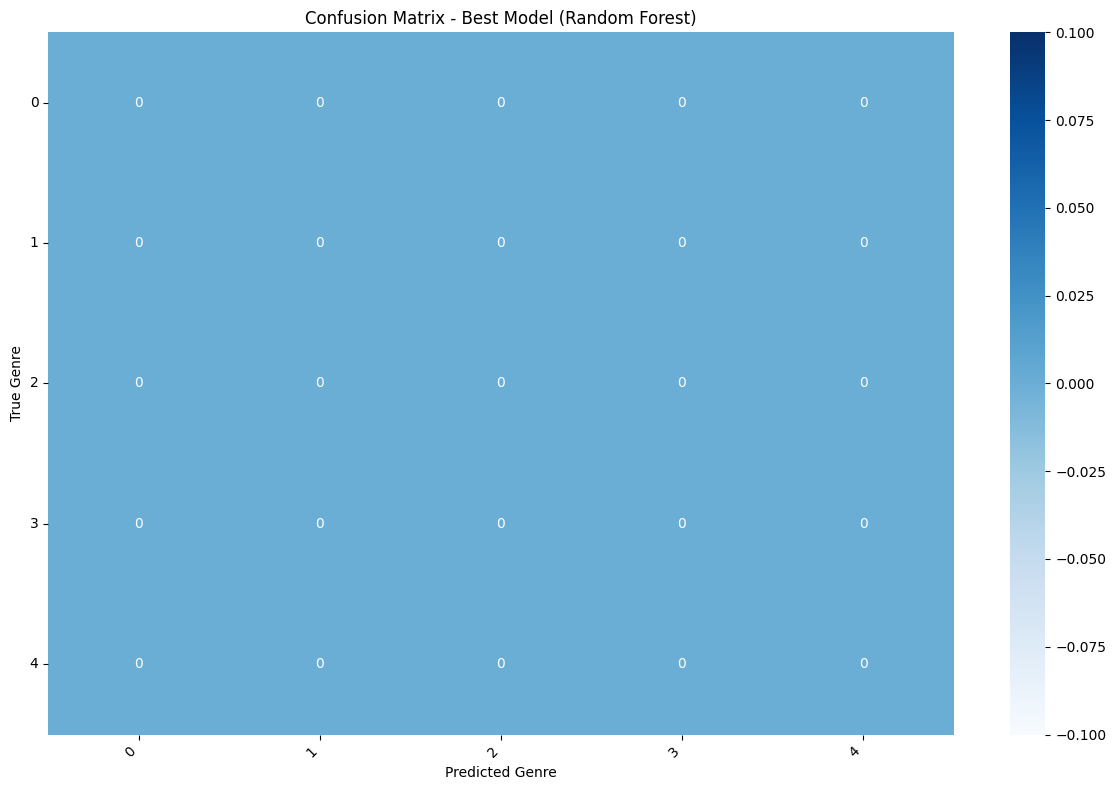

### Conclusion
**Random Forest** was the top performer after tuning, reaching **0.8064** accuracy (baseline **0.8037**, change **+0.0027**).

It likely performed best because ensemble trees capture non-linear feature interactions and reduce overfitting through averaging.

The main classification challenges were confusions between: **no dominant confusion pair stood out.**.

In [47]:
from sklearn.metrics import confusion_matrix
from IPython.display import Markdown, display

# Select best-performing model by tuned accuracy
best_model_name = summary_df.loc[summary_df['Tuned Accuracy'].idxmax(), 'Model']
prediction_bank = {
    'SVM': (y_test_svm_best, predict_svm_best_saved),
    'Random Forest': (y_test_rf_best, predict_rf_best_saved),
    'MLP': (y_test_mlp_best, predict_mlp_best_saved),
}

y_true_best, y_pred_best = prediction_bank[best_model_name]
labels = sorted(pd.Series(y_true_best).astype(str).unique())

# Confusion matrix heatmap for the best model
cm = confusion_matrix(y_true_best, y_pred_best, labels=labels)
plt.figure(figsize=(12, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
)
plt.title(f'Confusion Matrix - Best Model ({best_model_name})')
plt.xlabel('Predicted Genre')
plt.ylabel('True Genre')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Identify top genre confusions (off-diagonal)
cm_off_diag = cm.copy()
np.fill_diagonal(cm_off_diag, 0)
flat_idx = np.argsort(cm_off_diag.ravel())[::-1]
top_confusions = []
for idx in flat_idx:
    count = int(cm_off_diag.ravel()[idx])
    if count == 0:
        break
    i, j = np.unravel_index(idx, cm_off_diag.shape)
    top_confusions.append(f"{labels[i]} -> {labels[j]} ({count})")
    if len(top_confusions) == 3:
        break

reason_map = {
    'SVM': 'its margin-based decision boundaries handle high-dimensional standardized audio features effectively.',
    'Random Forest': 'ensemble trees capture non-linear feature interactions and reduce overfitting through averaging.',
    'MLP': 'the neural network learns complex non-linear relationships after feature scaling.',
}

best_row = summary_df.loc[summary_df['Model'] == best_model_name].iloc[0]
confusion_text = ', '.join(top_confusions) if top_confusions else 'no dominant confusion pair stood out.'

conclusion_text = (
    f"### Conclusion\n"
    f"**{best_model_name}** was the top performer after tuning, reaching **{best_row['Tuned Accuracy']:.4f}** accuracy "
    f"(baseline **{best_row['Baseline Accuracy']:.4f}**, change **{best_row['Improvement']:+.4f}**).\n\n"
    f"It likely performed best because {reason_map[best_model_name]}\n\n"
    f"The main classification challenges were confusions between: **{confusion_text}**."
)

display(Markdown(conclusion_text))


### Random Forest feature importance
Random Forest provides feature importances directly via `feature_importances_`, which helps interpret which audio descriptors drive genre separation.


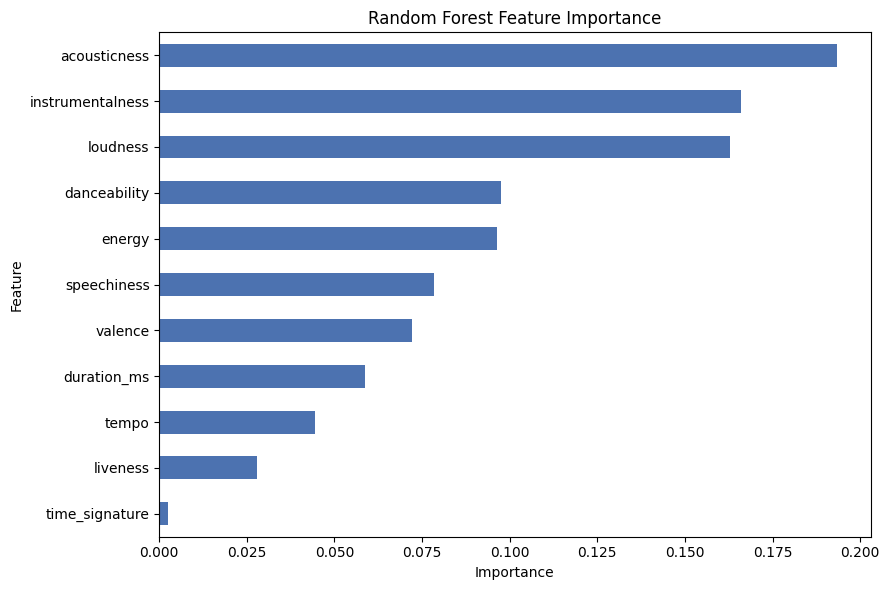

Most important features were 'acousticness' and 'instrumentalness'. That is musically plausible because genre boundaries are often driven by intensity, rhythm, and acoustic texture cues.


In [48]:
# Feature importance plot from the tuned Random Forest model
rf_importances = pd.Series(
    model_rf_best.best_estimator_.feature_importances_,
    index=X.columns,
).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
rf_importances.plot(kind='barh', color='#4c72b0')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

top_feature = rf_importances.index[-1]
runner_up = rf_importances.index[-2]
print(
    f"Most important features were '{top_feature}' and '{runner_up}'. "
    "That is musically plausible because genre boundaries are often driven by intensity, rhythm, and acoustic texture cues."
)
